In [1]:
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Styling
import matplotlib.style as style

style.use("fivethirtyeight")

# Statistics
from scipy.stats import zscore, norm

# Sklearn - Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.impute import SimpleImputer

# Create preprocessing pipeline with ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# Sklearn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression


# Sklearn - Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Imbalanced Learning
# from imblearn.over_sampling import SMOTE


# Set display options for better readability

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
np.random.seed(42)

# Define the data file path
DATA_PATH = "student-data-25s3.csv"
TARGET = "G3"  # Define the target variable

# 1. Data Preparation

Load and inspect the dataset for quality issues.

In [3]:
# Load the data
df = pd.read_csv(DATA_PATH)

# Basic info
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (650, 25)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,4,4,at_home,teacher,course,2,2,0,no,yes,no,no,4,3,4,3,4,0,11,11
1,GP,F,17,U,GT3,1,1,at_home,other,course,1,2,0,no,yes,yes,no,5,3,3,3,2,9,11,11
2,GP,F,15,U,LE3,1,1,at_home,other,other,1,2,0,no,yes,yes,no,4,3,2,3,6,12,13,12
3,GP,F,15,U,GT3,4,2,health,services,home,1,3,0,yes,yes,yes,yes,3,2,2,5,0,14,14,14
4,GP,F,16,U,GT3,3,3,other,other,home,1,2,0,no,yes,no,no,4,3,2,5,0,11,13,13


## 2.1 Check Duplicates

In [4]:
# Count duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# View duplicate rows (if any)
if dup_count > 0:
    display(df[df.duplicated(keep=False)])

# Remove duplicates (uncomment to use)
# df = df.drop_duplicates()
# print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 6


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
58,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
59,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
60,GP,M,15,U,LE3,1,2,other,at_home,home,1,2,0,yes,yes,yes,no,4,3,2,5,0,14,13,14
299,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
300,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
301,GP,F,20,R,GT3,2,1,other,other,course,2,2,0,yes,no,yes,yes,1,2,3,2,8,10,12,12
448,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17
468,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17
473,MS,F,16,R,GT3,4,4,teacher,teacher,course,2,3,0,yes,yes,yes,yes,4,2,2,4,6,16,16,17


## 2.2 Check Null Values

In [5]:
# Count null values per column
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percent': null_percent
})
print(null_summary[null_summary['null_count'] > 0])

# Total nulls
print(f"\nTotal null values: {df.isnull().sum().sum()}")

           null_count  null_percent
school              1          0.15
sex                 1          0.15
Mjob                1          0.15
Fjob                1          0.15
studytime           3          0.46
G1                  1          0.15

Total null values: 8


In [38]:
# view rows with nulls
display(df[df.isnull().any(axis=1)])

,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
119,GP,M,15,U,GT3,3,4,other,other,reputation,1,NaN,0,no,yes,yes,no,3,4,3,4,2,14,13,14
120,GP,F,15,U,GT3,1,2,at_home,services,course,1,NaN,0,no,yes,yes,no,3,2,3,1,0,14,14,14
208,GP,M,16,U,GT3,2,3,NaN,other,home,2,1,0,no,yes,yes,no,5,3,3,3,0,NaN,12,12
209,GP,F,17,U,LE3,2,4,other,NaN,course,1,2,0,yes,yes,yes,yes,4,3,2,5,8,4,15,16
324,GP,M,18,U,GT3,1,2,at_home,other,home,2,NaN,0,no,no,yes,no,3,4,4,4,10,10,10,11
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19


## 2.3 Check Unique Values

In [6]:
# Show unique values for each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    # Show unique values and their counts
    
    for val in unique_vals:
        count = (df[col] == val).sum()
        print(f"  {val}: {count}")
    
    print("-----------")
    

school: 3 unique values
  GP: 423
  MS: 226
  nan: 0
-----------
sex: 3 unique values
  F: 384
  M: 265
  nan: 0
-----------
age: 14 unique values
  18: 138
  17: 178
  15: 111
  16: 173
  19: 32
  22: 1
  20: 8
  21: 2
  105: 1
  106: 1
  115: 1
  2O: 1
  1O: 1
  170: 2
-----------
address: 3 unique values
  U: 449
  R: 200
  0: 1
-----------
famsize: 3 unique values
  GT3: 456
  LE3: 193
  0: 1
-----------
Medu: 5 unique values
  4: 174
  1: 145
  3: 139
  2: 186
  0: 6
-----------
Fedu: 5 unique values
  4: 130
  1: 175
  2: 209
  3: 129
  0: 7
-----------
Mjob: 10 unique values
  at_home: 127
  health: 46
  other: 262
  services: 130
  teacher: 73
  service: 3
  nan: 0
  at home: 4
  home: 3
  0: 1
-----------
Fjob: 8 unique values
  teacher: 37
  other: 360
  services: 179
  health: 23
  at_home: 44
  nan: 0
  others: 5
  0: 1
-----------
reason: 5 unique values
  course: 286
  other: 71
  home: 150
  reputation: 142
  0: 1
-----------
traveltime: 4 unique values
  2: 216
  1: 364

In [44]:
# Function to check domain constraint violations
def check_domain_violations(df, col, valid_mask):
    """
    Check values outside domain constraints.

    Args:
        df: DataFrame
        col: Column name to check
        valid_mask: Boolean mask where True = valid values

    Returns:
        Count of violations and displays invalid rows
    """
    violations = df[~valid_mask]
    print(f"{col}: {len(violations)} values outside domain constraints")
    if len(violations) > 0:
        display(violations[[col]])
    
    print("\n-----------\n")
    # return len(violations)

Check domain violations


In [45]:
# Example: Check if 'G3' is between 0 and 100
check_domain_violations(df, "G3", (df["G3"] >= 0) & (df["G3"] <= 100))

G3: 0 values outside domain constraints

-----------



In [51]:
# Check for leading/trailing whitespace in string columns
string_cols = df.select_dtypes(include="object").columns
isExtraWhitespace = False

for col in string_cols:
    whitespace_count = (df[col] != df[col].str.strip()).sum()
    if whitespace_count > 0:
        isExtraWhitespace = True
        print(f"{col}: {whitespace_count} entries with extra whitespace")
        print("-----------")
if not isExtraWhitespace:
    print("No leading/trailing whitespace issues detected in string columns.")


school: 1 entries with extra whitespace
-----------
sex: 1 entries with extra whitespace
-----------
Mjob: 1 entries with extra whitespace
-----------
Fjob: 1 entries with extra whitespace
-----------
studytime: 3 entries with extra whitespace
-----------
G1: 1 entries with extra whitespace
-----------


In [50]:
# Check for inconsistent casing in string columns
isInconsistentCasing = False
for col in string_cols:
    
    unique_vals = df[col].dropna().unique()
    lower_unique = df[col].str.lower().dropna().unique()

    if len(unique_vals) != len(lower_unique):
        print(f"{col}: Possible casing inconsistencies")
        print(f"  Original unique: {list(unique_vals)}")
        print(f"  Lowercased unique: {list(lower_unique)}")
        print("-----------")
        isInconsistentCasing = True

if not isInconsistentCasing:
    print("No casing issues detected in string columns.")

No casing issues detected in string columns.


## 2.5 Check Outliers

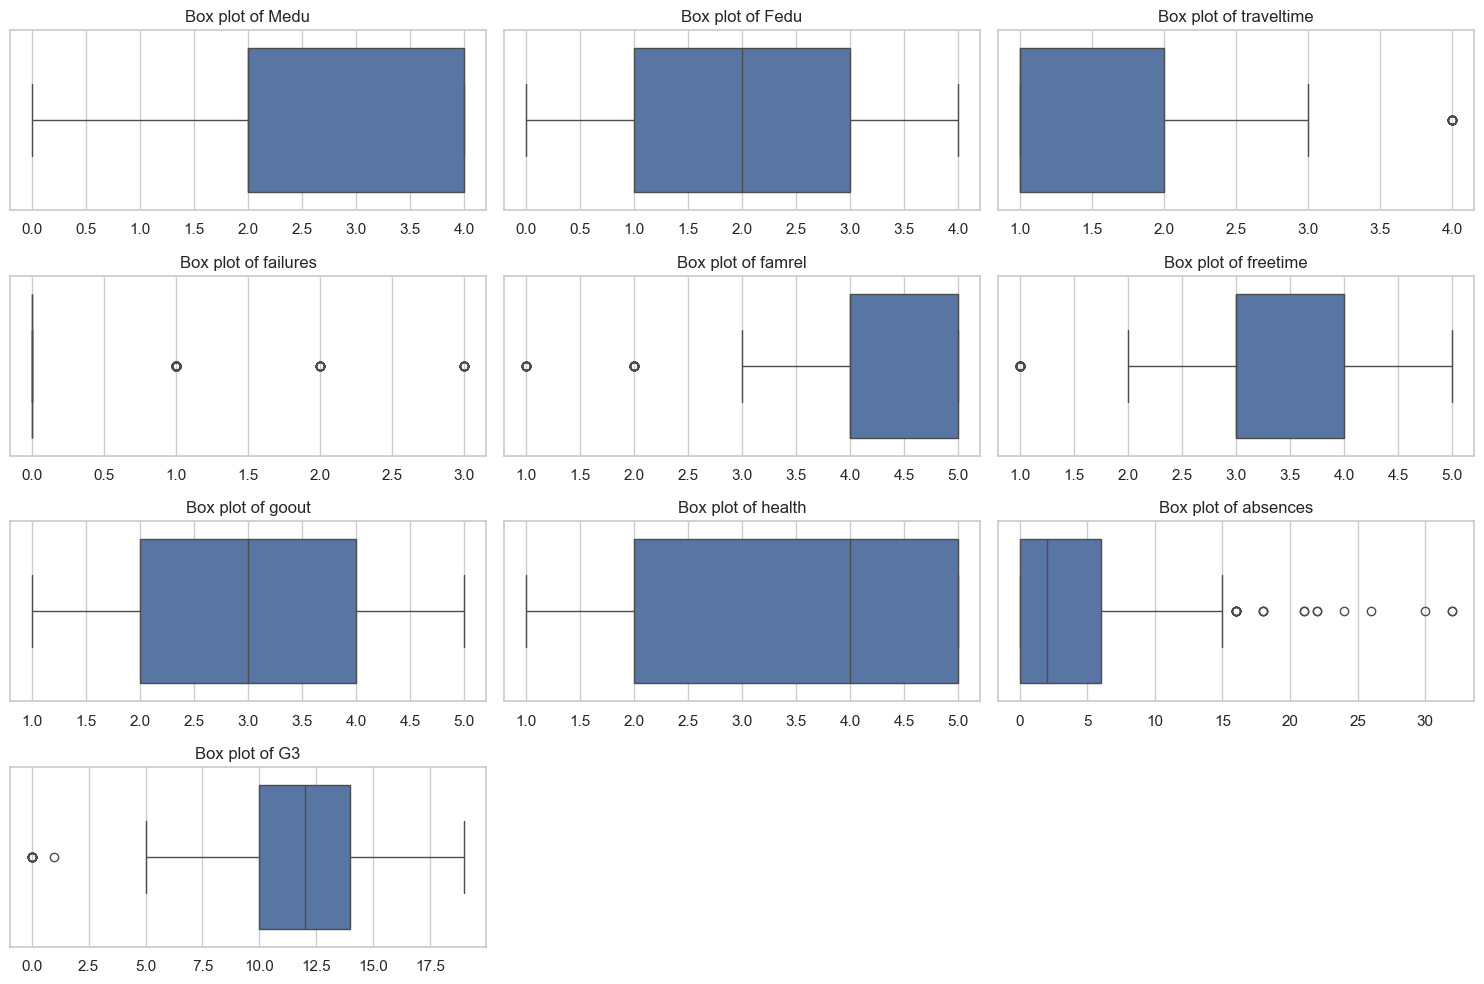

In [37]:
# display all box plots
_, subs = plt.subplots(math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10))

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    sns.boxplot(x=df[col], ax=subs[i // 3, i % 3])
    subs[i // 3, i % 3].set_title(f'Box plot of {col}')
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

In [35]:
# display number of outliers per numerical column based on 1.5*IQR rule
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")



Medu: 0 outliers
Fedu: 0 outliers
traveltime: 17 outliers
failures: 101 outliers
famrel: 51 outliers
freetime: 44 outliers
goout: 0 outliers
health: 0 outliers
absences: 22 outliers
G3: 16 outliers


# 3. Data Cleaning

In [54]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(644, 25)

In [ ]:
# function to remove rows with domain constraint violations
def remove_domain_violations(df, col, valid_mask):
    """
    Remove rows with values outside domain constraints.

    Args:
        df: DataFrame
        col: Column name to check
        valid_mask: Boolean mask where True = valid values

    Returns:
        DataFrame with invalid rows removed
    """
    invalid_mask = ~valid_mask
    invalid_indices = df[invalid_mask].index.tolist()
    print(f"Removing {len(invalid_indices)} rows with invalid {col} values")
    df = df[valid_mask]
    print(f"Shape after removing domain violations: {df.shape}\n")
    # return df

In [68]:
# Remove domain validation
df = remove_domain_violations(df, "G3", (df["G3"] >= 0) & (df["G3"] <= 5))

Removing 179 rows with invalid G3 values
Shape after removing domain violations: (17, 25)



In [ ]:
# Trim whitespace and standardize casing in string columns
string_cols = df.select_dtypes(include='object').columns

for col in string_cols:
    df[col] = df[col].str.strip().str.lower()

print("Trimmed whitespace and converted to lowercase for string columns")
df[string_cols].head()

In [73]:
# Convert columns to correct data types
# Example: Convert 'age' to int, 'date' to datetime
# df['date'] = pd.to_datetime(df['date'])
# convert to categorical or ordinal as needed


df['age'] = df['age'].astype(int)
df['Medu'] = pd.Categorical(df['Medu'], ordered=True)
df['school'] = pd.Categorical(df['school'])

df.dtypes

C:\Users\USER\AppData\Local\Temp\ipykernel_15952\1687076440.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = df['age'].astype(int)
C:\Users\USER\AppData\Local\Temp\ipykernel_15952\1687076440.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Medu'] = pd.Categorical(df['Medu'], ordered=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_15952\1687076440.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

school        category
sex             object
age              int64
address         object
famsize         object
Medu          category
Fedu             int64
Mjob            object
Fjob            object
reason          object
traveltime       int64
studytime       object
failures         int64
activities      object
higher          object
internet        object
romantic        object
famrel           int64
freetime         int64
goout            int64
health           int64
absences         int64
G1              object
G2              object
G3               int64
dtype: object

In [ ]:
# View categories of an ordinal column (with order)
# print(f"Medu categories: {df['Medu'].cat.categories.tolist()}")
# print(f"Medu is ordered: {df['Medu'].cat.ordered}")

Medu categories: [1, 2, 3, 4]
Medu is ordered: True


In [76]:
# Remove outliers using IQR method
def remove_outliers_iqr(df, col):
    """Remove outliers from a column using 1.5*IQR rule."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_indices = df[outlier_mask].index.tolist()
    
    if len(outlier_indices) > 0:
        print(f"{col}: Removed {len(outlier_indices)} outliers")
    return df[~outlier_mask]

In [77]:
df = remove_outliers_iqr(df, "age")

age: Removed 1 outliers


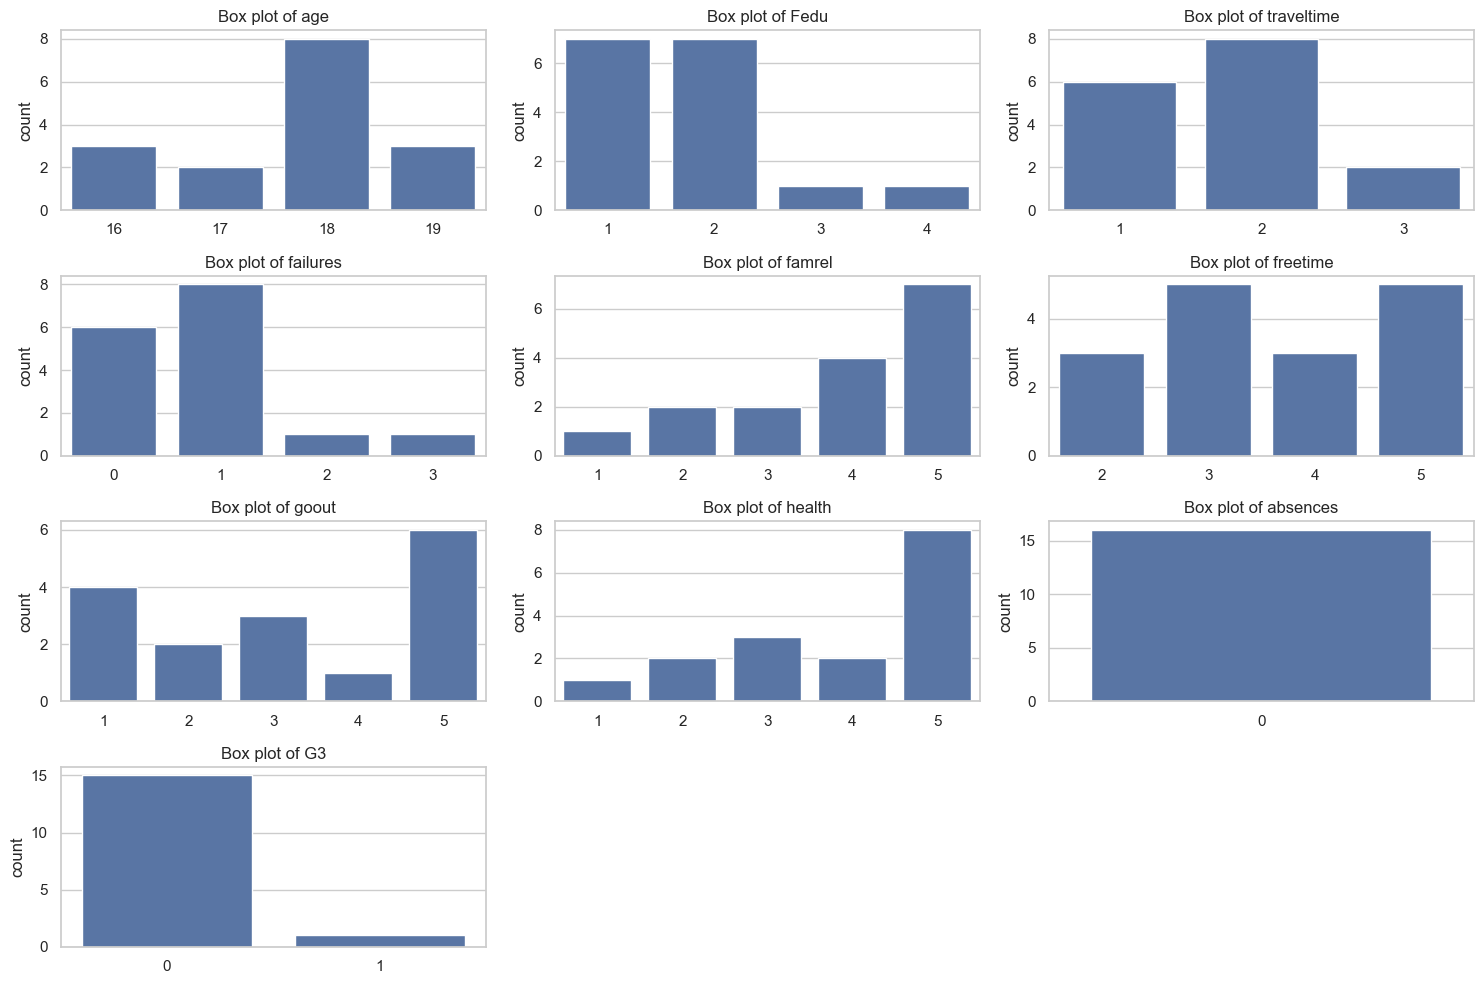

In [ ]:
# display all count plots
_, subs = plt.subplots(
    math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10)
)

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    sns.countplot(x=df[col], ax=subs[i // 3, i % 3])
    subs[i // 3, i % 3].set_title(f"Count plot of {col}")
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

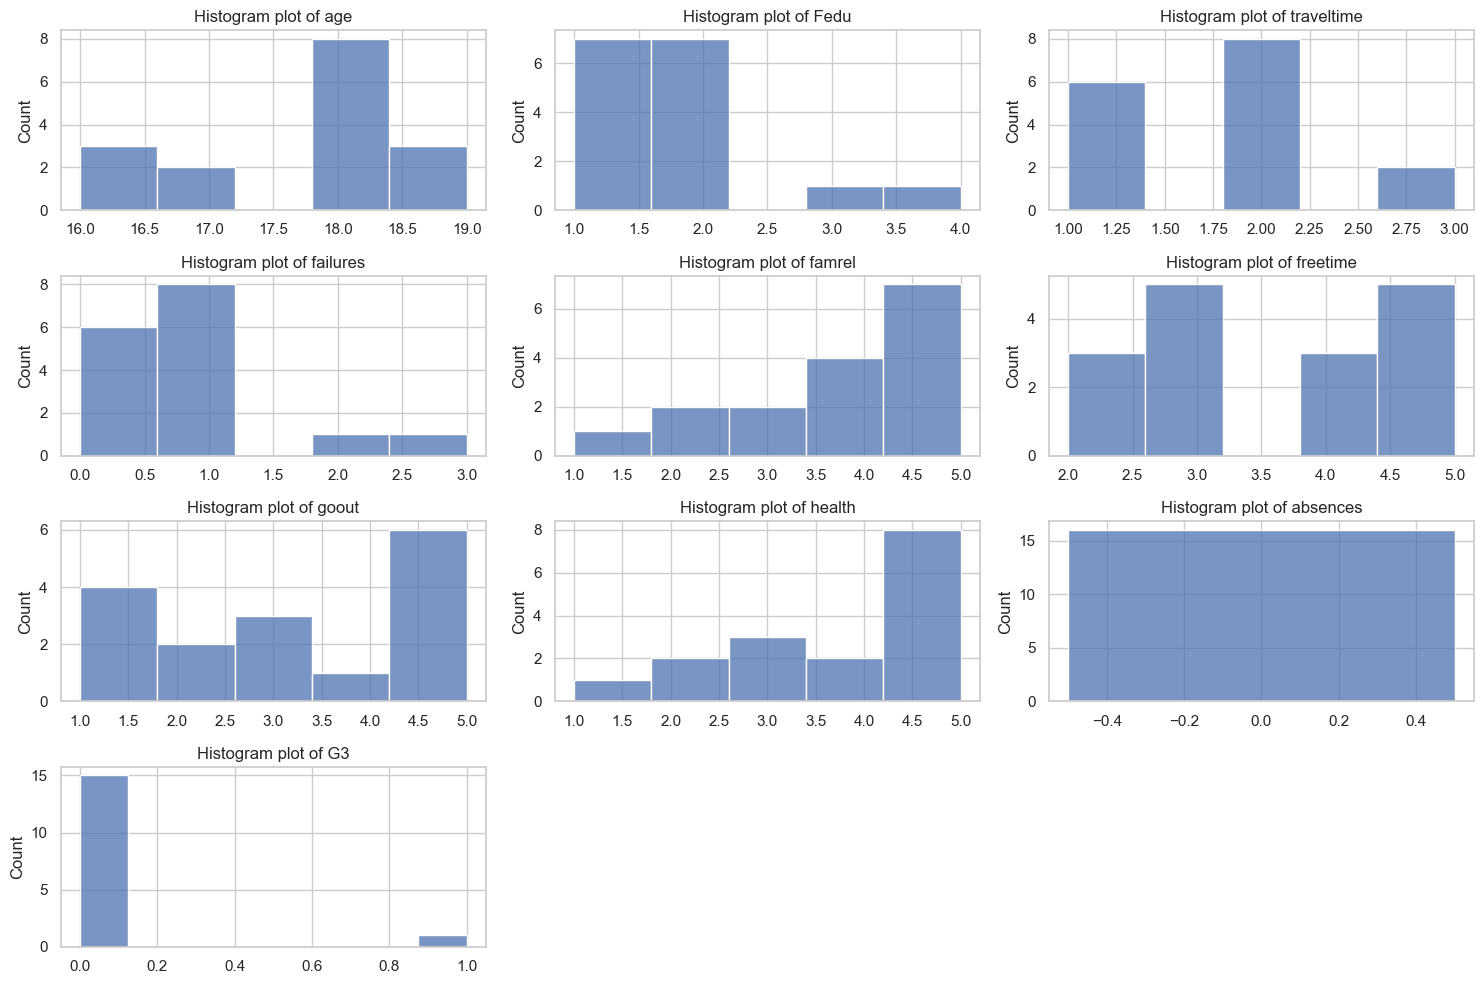

In [80]:
# display all histogram plots
_, subs = plt.subplots(
    math.ceil(len(df.select_dtypes(include=np.number).columns) / 3), 3, figsize=(15, 10)
)

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    sns.histplot(x=df[col], ax=subs[i // 3, i % 3])
    subs[i // 3, i % 3].set_title(f"Histogram plot of {col}")
    subs[i // 3, i % 3].set_xlabel("")

# Hide empty subplots
for j in range(len(df.select_dtypes(include=np.number).columns), len(subs.flatten())):
    subs[j // 3, j % 3].axis("off")

plt.tight_layout()
plt.show()

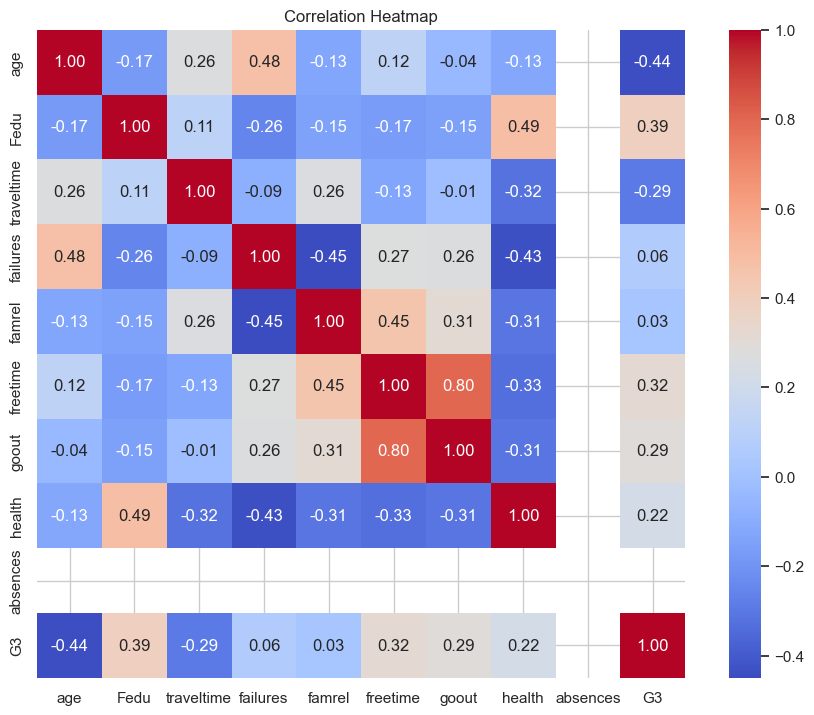

In [82]:
# correlation heatmap
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()


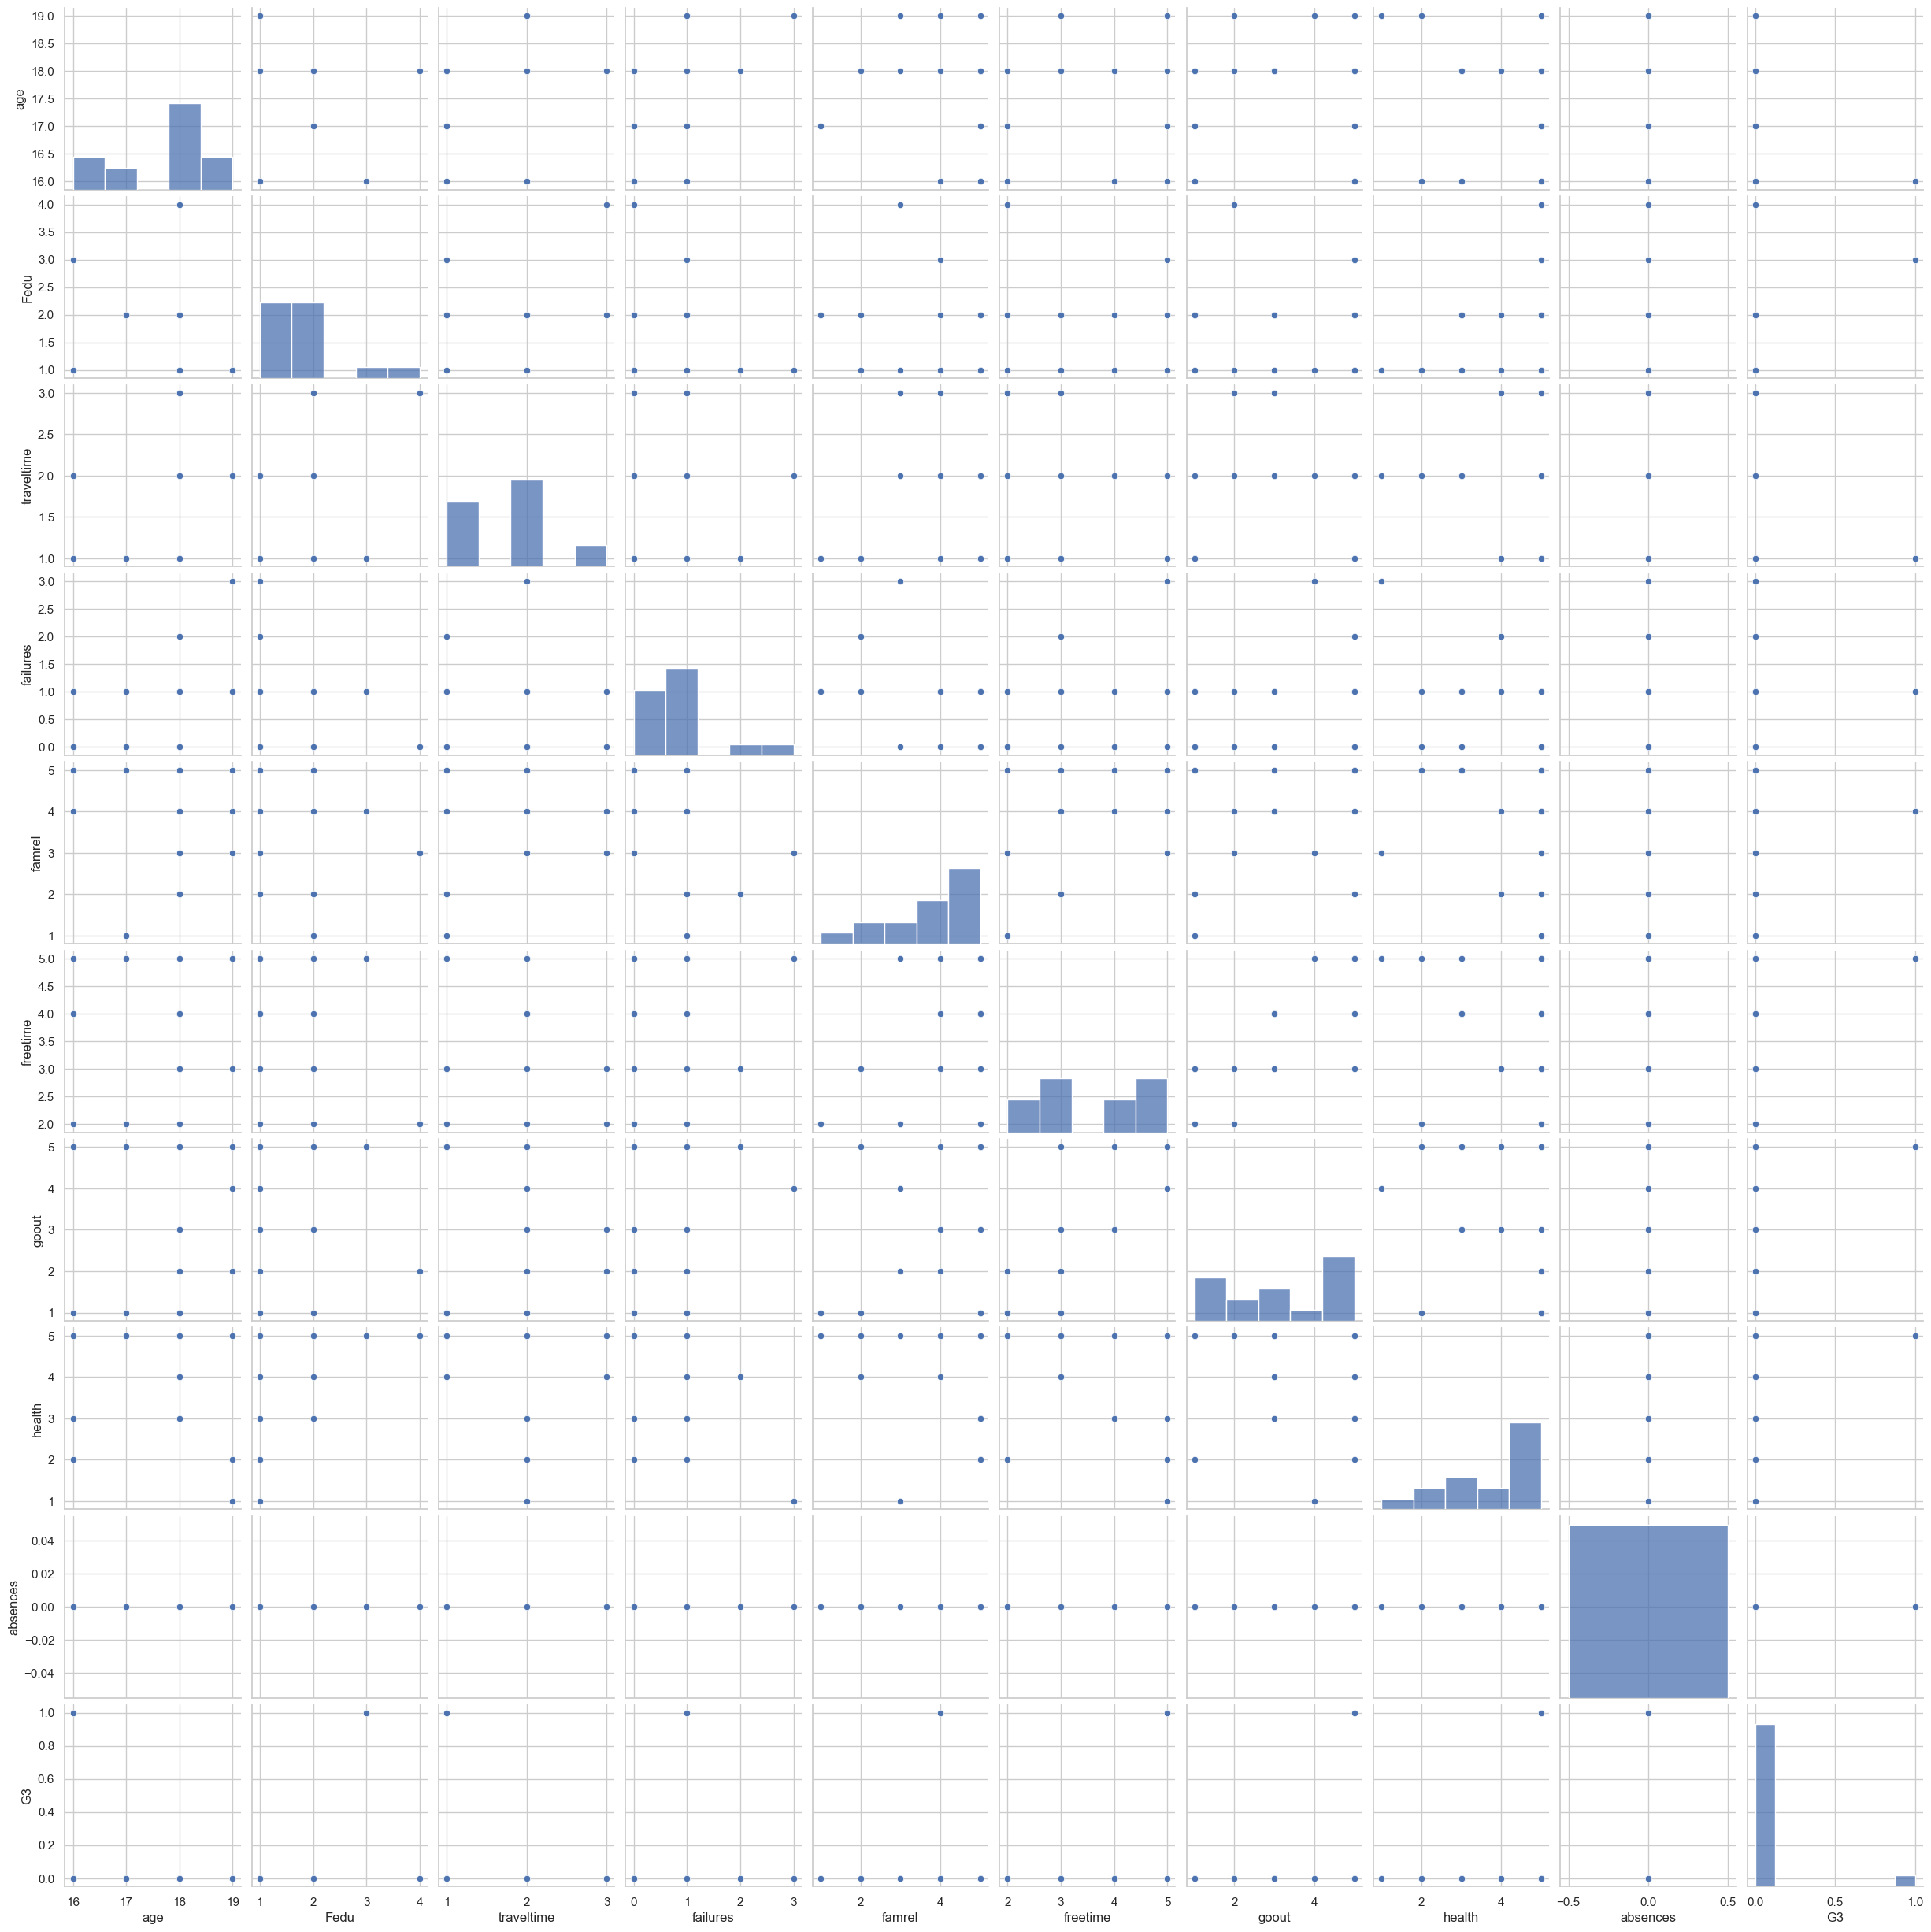

In [81]:
sns.pairplot(df.select_dtypes(include=np.number))

## 3.1 Encoding Categorical Variables

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# remove target from categorical and numerical columns
if TARGET in cat_cols:
    cat_cols.remove(TARGET)
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

# 3. Feature Preprocessing# Data Modelling

In [ ]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

y = y.apply(lambda x: 1 if x >= 10 else 0)

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

In [ ]:
# Define column groups (customize these based on your data)

# Columns for one-hot encoding (nominal categorical - no order)
onehot_cols = cat_cols  # e.g., ['school', 'sex', 'address']

# Columns for ordinal encoding (ordinal categorical - with order)
ordinal_cols = []  # columns with natural order
ord_categories = {
    # "size": ["small", "medium", "large"],
    # "education": ["high_school", "bachelor", "master"],
}

# Columns for standardization (z-score)
standardize_cols = []  # e.g., ['age', 'absences']

# Columns for min-max scaling
minmax_cols = numerical_cols  # e.g., ['G1', 'G2']

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
                ]
            ),
            onehot_cols,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("minmax", MinMaxScaler()),
                ]
            ),
            minmax_cols,
        ),
        # ('ordinal', OrdinalEncoder(categories=list(ord_categories.values())), ordinal_cols),
        # ('standardize', StandardScaler(), standardize_cols),
    ],
    remainder="passthrough",  # Drop columns not specified
)

# Create preprocessing pipeline
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
    ]
)

# Fit the pipeline
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

In [ ]:
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

In [ ]:
def train_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    print("Model accuracy for train set: {0:.3f}".format(model.score(X_train, y_train)))
    print("Model accuracy for test set: {0:.3f}".format(model.score(X_test, y_test)))

    y_pred = model.predict(X_test)

    # Classification Report
    print("\n{}".format(classification_report(y_test, y_pred)))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Accuracy Score
    auc = accuracy_score(y_test, y_pred)
    print("\nAccuracy Score: ", round(auc, 3))

    # ROC Curve
    model_roc_auc = roc_auc_score(y_test, model.predict(X_test))
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.figure(figsize=(12.8, 6))
    plt.plot(fpr, tpr, label="AUC = {})".format(round(model_roc_auc, 4)))
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic")
    plt.legend(loc="lower right")
    plt.show()

    return model

# Base Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42)
lr_model = train_and_plot(lr, X_train_pre, y_train, X_test_pre, y_test)

## LR with hyperparameter tuning

In [ ]:
LR = LogisticRegression()

params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "max_iter": [100, 110, 120, 130, 140],
}

skf = StratifiedKFold(n_splits=10)
LR_hyper = GridSearchCV(LR, param_grid=params, n_jobs=-1, cv=skf)

lr_hyper_model = train_and_plot(LR_hyper, X_train_pre, y_train, X_test_pre, y_test)

# Base Decision Tree Model

In [ ]:
# Base Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

dt_model = train_and_plot(dt, X_train_pre, y_train, X_test_pre, y_test)

# Base KNN model

In [ ]:
# KNN b

knn = KNeighborsClassifier()
knn_model = train_and_plot(knn, X_train_pre, y_train, X_test_pre, y_test)

In [ ]:
# KNN with hyperparameter tuning
KNN = KNeighborsClassifier()

params = {
    "n_neighbors": list(range(1, 40, 2)),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

skf = StratifiedKFold(n_splits=10)
KNN_hyper = GridSearchCV(KNN, param_grid=params, n_jobs=-1, cv=skf)

knn_model_hyper = train_and_plot(KNN_hyper, X_train_pre, y_train, X_test_pre, y_test)

# Base Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf_model = train_and_plot(rf, X_train_pre, y_train, X_test_pre, y_test)

# Regression

In [ ]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

In [ ]:
pipeline.fit(X_train, y_train)
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

In [ ]:
def train_and_plot_regression(model, X_train, y_train, X_test, y_test):
    """Train regression model and display relevant metrics"""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R² Score
    print(f"R² Score (Train): {r2_score(y_train, y_train_pred):.3f}")
    print(f"R² Score (Test):  {r2_score(y_test, y_test_pred):.3f}")

    # MSE & RMSE
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    print(f"\nMSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")

    # MAE
    mae = mean_absolute_error(y_test, y_test_pred)
    print(f"MAE:  {mae:.3f}")

    # Residual Plot
    residuals = y_test - y_test_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Predicted vs Actual
    axes[0].scatter(y_test, y_test_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title("Predicted vs Actual")

    # Residuals distribution
    axes[1].hist(residuals, bins=30, edgecolor="black")
    axes[1].set_xlabel("Residuals")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Residuals Distribution")

    plt.tight_layout()
    plt.show()

    return model

## Base Linear Regression

In [ ]:
lr = LinearRegression()

lr_model = train_and_plot_regression(lr, X_train_pre, y_train, X_test_pre, y_test)